In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


데이터를 로드 중입니다...
로드 완료!

[Top 15 진료과 (Services)]
   Service   Count
0      MED  286528
1     CMED   54452
2     SURG   51640
3     OMED   33549
4    ORTHO   26991
5     NMED   26709
6      OBS   24923
7    NSURG   16795
8    CSURG   13421
9    VSURG   12385
10   PSYCH    9592
11   TRAUM    8961
12     GYN    7935
13      GU    7083
14   TSURG    5767


/tmp/ipython-input-1050761859.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_services, x='Count', y='Service', palette='viridis')


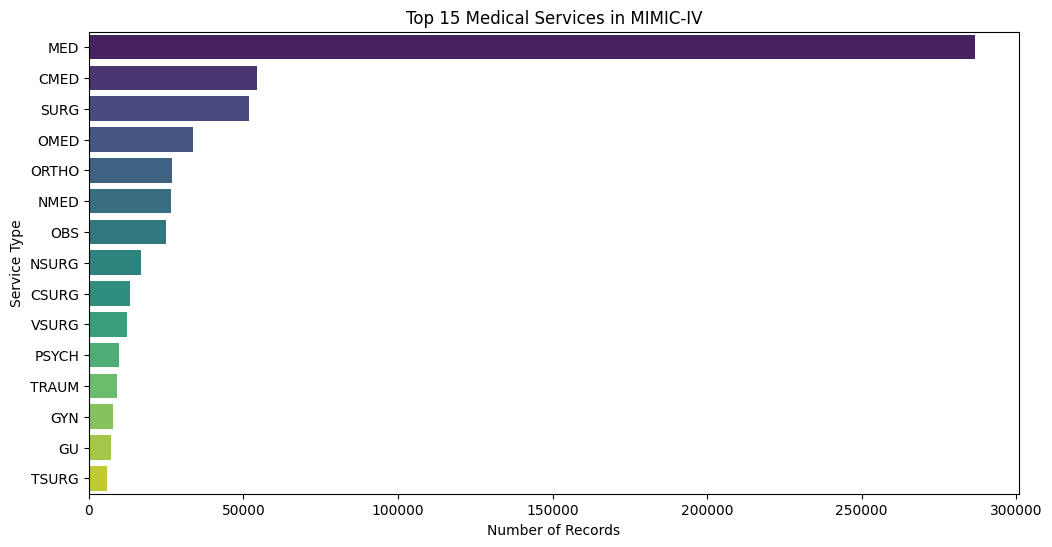


[Top 20 빈출 질병 (ICD Codes)]
   icd_code                                         long_title   Count
0      4019                 Unspecified essential hypertension  102368
1      E785                        Hyperlipidemia, unspecified   84570
2       I10                   Essential (primary) hypertension   83775
3      2724               Other and unspecified hyperlipidemia   67293
4    Z87891            Personal history of nicotine dependence   62806
5      K219  Gastro-esophageal reflux disease without esoph...   56157
6     53081                                  Esophageal reflux   48628
7     25000  Diabetes mellitus without mention of complicat...   43077
8      F329  Major depressive disorder, single episode, uns...   41876
9     I2510  Atherosclerotic heart disease of native corona...   41550
10     F419                      Anxiety disorder, unspecified   38911
11    42731                                Atrial fibrillation   37070
12     4280              Congestive heart failure

/tmp/ipython-input-1050761859.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_diseases, x='Count', y='long_title', palette='rocket')


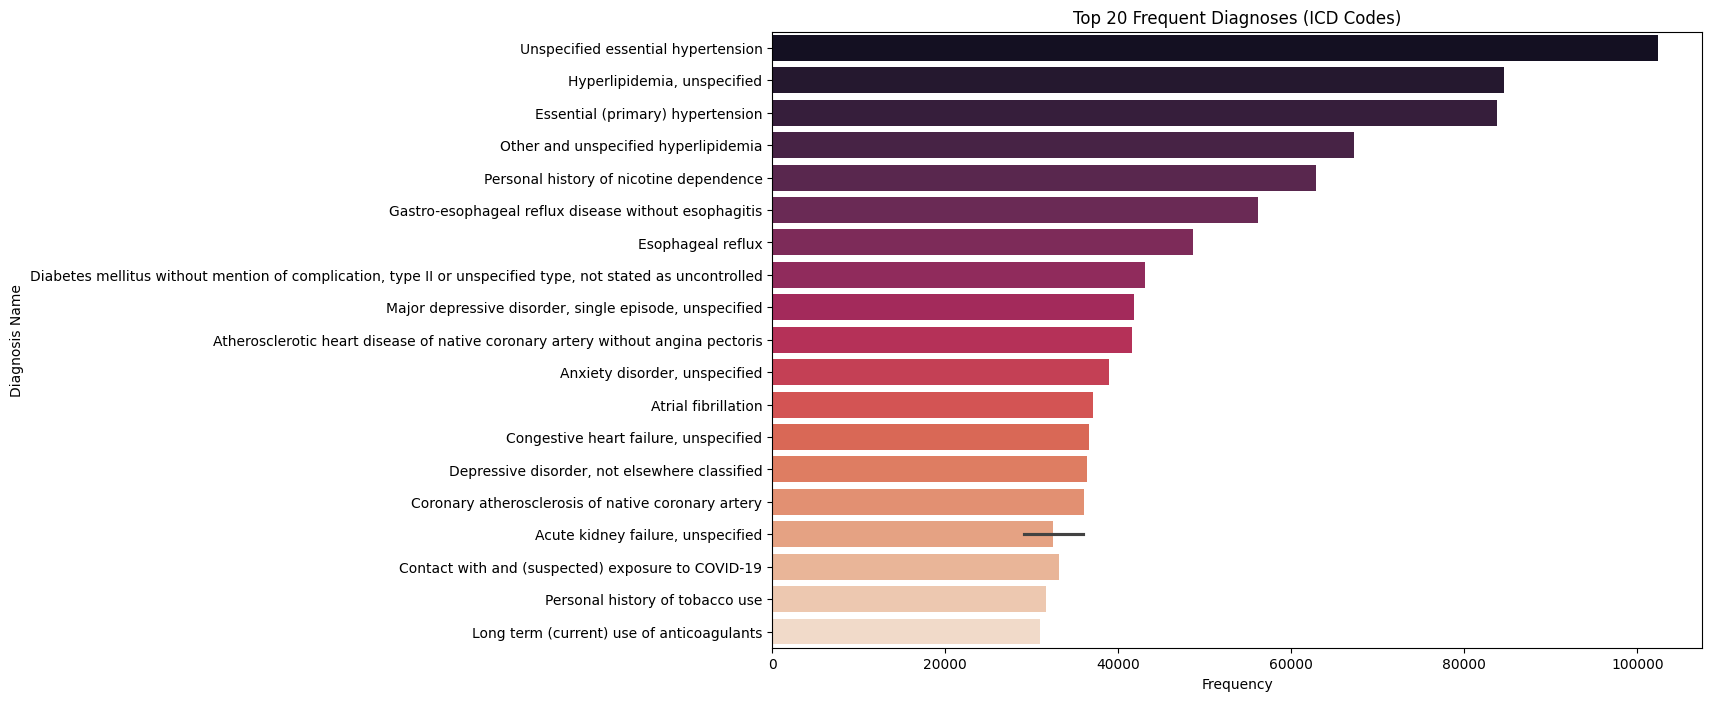

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 데이터 경로 설정
base_path = "/content/drive/MyDrive/DILAB/MARS/mimiciv_3.1/files/hosp"

# 파일 경로 정의
diag_path = os.path.join(base_path, 'diagnoses_icd.csv')
dict_path = os.path.join(base_path, 'd_icd_diagnoses.csv')
serv_path = os.path.join(base_path, 'services.csv')

# 데이터 로드
print("데이터를 로드 중입니다...")
df_diag = pd.read_csv(diag_path)
df_dict = pd.read_csv(dict_path)
df_serv = pd.read_csv(serv_path)
print("로드 완료")

# 상위 진료과 (Medical Specialties/Services) 분석
top_services = df_serv['curr_service'].value_counts().head(15).reset_index()
top_services.columns = ['Service', 'Count']

print("\n[Top 15 진료과 (Services)]")
print(top_services)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=top_services, x='Count', y='Service', palette='viridis')
plt.title('Top 15 Medical Services in MIMIC-IV')
plt.xlabel('Number of Records')
plt.ylabel('Service Type')
plt.show()

# 상위 질병 (Diagnoses) 분석
top_diag_codes = df_diag['icd_code'].value_counts().head(20).reset_index()
top_diag_codes.columns = ['icd_code', 'Count']

top_diseases = pd.merge(top_diag_codes, df_dict, on='icd_code', how='left')

top_diseases = top_diseases.drop_duplicates(subset=['icd_code']).reset_index(drop=True)

print("\n[Top 20 빈출 질병 (ICD Codes)]")
print(top_diseases[['icd_code', 'long_title', 'Count']])

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=top_diseases, x='Count', y='long_title', palette='rocket')
plt.title('Top 20 Frequent Diagnoses (ICD Codes)')
plt.xlabel('Frequency')
plt.ylabel('Diagnosis Name')
plt.show()